# 📊 Unemployment Analysis with Python

### Oasis Infobyte Internship

**Track:** Data Science

**Task 2:** Unemployment Analysis with Python

---

## 🎯 Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on unemployment data in India to identify regional and temporal trends, with special focus on the impact of the COVID-19 pandemic.

---

## 📚 Libraries Used

- pandas
- numpy
- matplotlib
- seaborn


In [44]:
# ==========================================
# STEP 1 : Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [45]:
# ==========================================
# STEP 2 : Load Dataset
# ==========================================

df = pd.read_csv("unemployment.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [46]:
# ==========================================
# STEP 3 : Dataset Inspection
# ==========================================

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [47]:
# Shape of Dataset
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 768
Columns : 7


In [48]:
# Column Names
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [49]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [50]:
# Missing Values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [51]:
# Duplicate Rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 27


## Observation

- The dataset contains unemployment information for different regions of India.
- It includes unemployment rate, employment, labour participation rate, area, and date.
- Some column names contain leading spaces and need cleaning.
- The Date column is currently stored as text and will be converted into datetime format in the next step.

# 🧹 STEP 4 : Data Cleaning

Before performing Exploratory Data Analysis (EDA), it is important to clean the dataset.

In this step, we will:

- Remove unwanted spaces from column names
- Convert the Date column to datetime format
- Check for missing values
- Remove duplicate rows
- Create Month and Year columns for time-series analysis

In [52]:
# ==========================================
# STEP 4 : Data Cleaning
# ==========================================

# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Display updated column names
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [53]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully.")

Date column converted successfully.


In [54]:
# Check Data Types

df.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

In [55]:
# Missing Values

df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [56]:
# Remove Duplicate Rows

df.drop_duplicates(inplace=True)

print("Duplicate rows removed successfully.")

Duplicate rows removed successfully.


In [57]:
# Create Month and Year columns

df["Month"] = df["Date"].dt.month_name()

df["Year"] = df["Date"].dt.year

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019.0


In [58]:
# Statistical Summary

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year
count,740,740.000000,7.400000e+02,740.000000,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716


## Observation

- Column names have been cleaned.
- Date column is successfully converted into datetime format.
- Month and Year columns have been created for time-series analysis.
- Dataset is now ready for Exploratory Data Analysis (EDA).


# 📊 STEP 5 : Region-wise Average Unemployment Rate

This visualization shows the average unemployment rate across different regions of India.

It helps identify which regions experience higher unemployment on average.

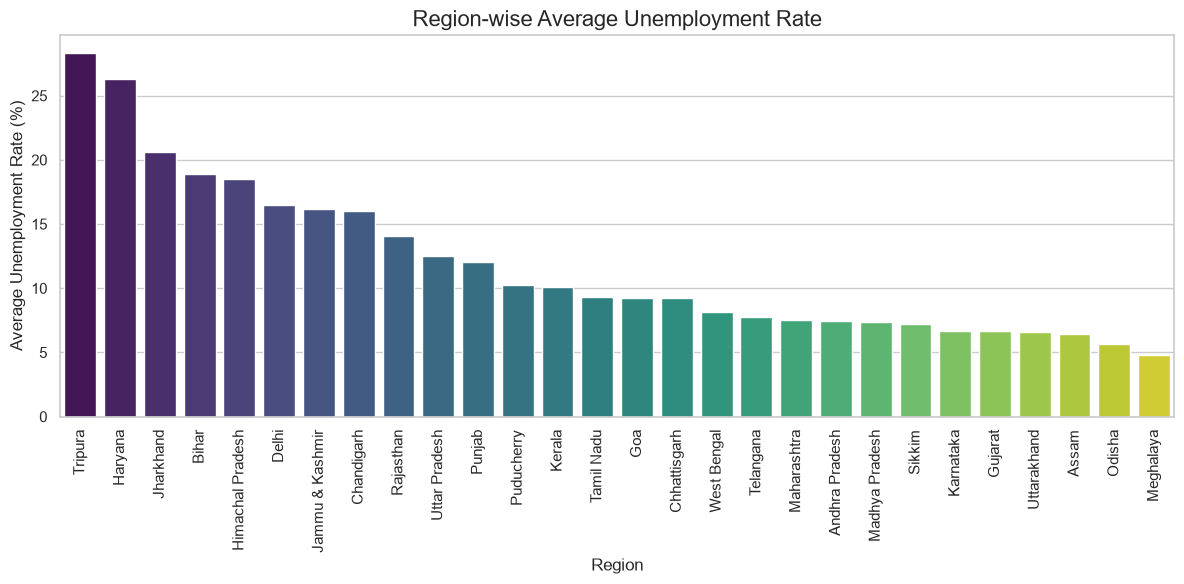

In [59]:
# ==========================================
# Region-wise Average Unemployment Rate
# ==========================================

region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region_avg.index,
    y=region_avg.values,
    palette="viridis"
)

plt.title("Region-wise Average Unemployment Rate", fontsize=16)

plt.xlabel("Region")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "outputs/region_wise_average_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- The chart shows the average unemployment rate across different regions.
- Regions with taller bars indicate higher average unemployment.
- This comparison helps identify areas that may require greater employment support.

# 📈 STEP 6 : Monthly Unemployment Trend

This analysis shows how the unemployment rate changed over different months.

It helps identify seasonal patterns and significant increases or decreases in unemployment over time.

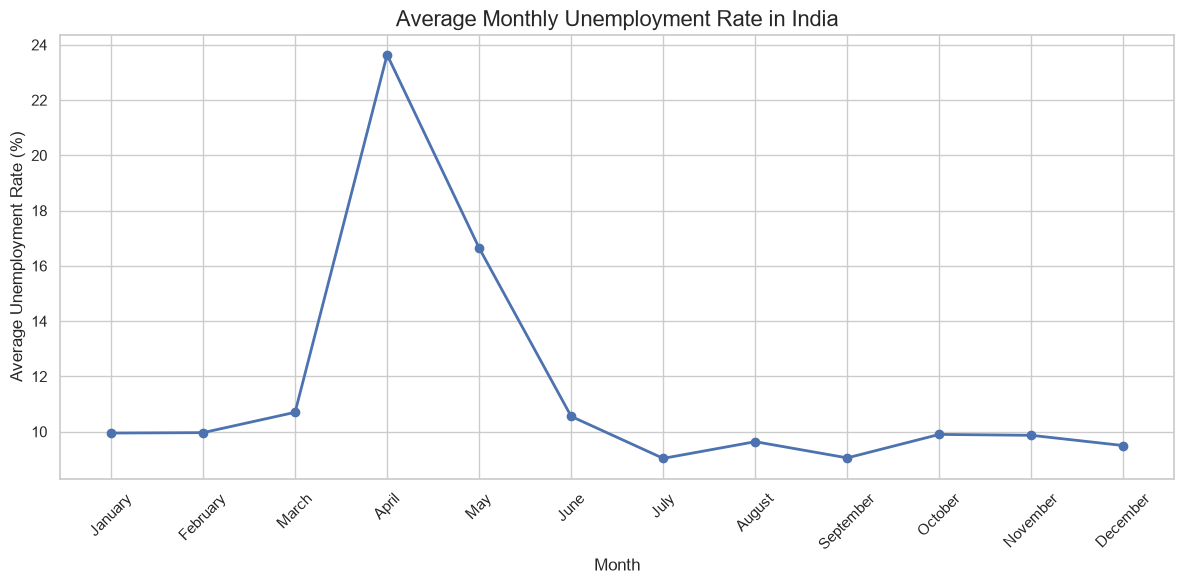

In [60]:
# ==========================================
# STEP 6 : Monthly Unemployment Trend
# ==========================================

# Calculate average unemployment rate by month
monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex([
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ])
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Unemployment Rate in India", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "outputs/monthly_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- The line chart shows the monthly variation in unemployment rates.
- Peaks indicate months with higher average unemployment.
- This visualization helps identify seasonal or economic trends throughout the year.

# 📈 STEP 7 : Time Series Analysis of Major States

## 🎯 Objective

Time series analysis helps us understand how unemployment rates changed over time in different states.

For this analysis, we will compare the unemployment trends of three major Indian states. This comparison highlights regional differences and shows how unemployment varied across different periods, including the COVID-19 pandemic.

The selected states are based on the available data in the dataset.

In [66]:
# ==========================================
# STEP 7 : Time Series Analysis
# ==========================================

# Display all available states/regions

regions = sorted(df["Region"].dropna().unique())

for region in regions:
    print(region)

Andhra Pradesh
Assam
Bihar
Chandigarh
Chhattisgarh
Delhi
Goa
Gujarat
Haryana
Himachal Pradesh
Jammu & Kashmir
Jharkhand
Karnataka
Kerala
Madhya Pradesh
Maharashtra
Meghalaya
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil Nadu
Telangana
Tripura
Uttar Pradesh
Uttarakhand
West Bengal


# 📈 STEP 7 : Time Series Analysis of Major States

## 🎯 Objective

Time-series analysis helps us understand how unemployment rates changed over time across different states.

For this analysis, we compare the unemployment trends of **Maharashtra**, **Karnataka**, and **Delhi**. These states are selected because they are among India's major economic regions and provide a meaningful comparison of unemployment patterns before and during the COVID-19 pandemic.

In [ ]:
# ==========================================
# STEP 7 : Time Series Analysis
# ==========================================

# Select three major states
selected_states = [
    "Maharashtra",
    "Karnataka",
    "Delhi"
]

# Filter the dataset
state_data = df[df["Region"].isin(selected_states)]

# Plot time series
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o",
    linewidth=2
)

plt.title("Unemployment Rate Over Time for Selected States", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="State")

plt.tight_layout()

# Save the figure
plt.savefig(
    "outputs/state_time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()